# Optimization: Experience Replay, Reward Shaping, and Hyperparameter Tuning

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand and implement an experience replay buffer
- Apply reward shaping and measure its effect in a small experiment
- Know the common Deep RL hyperparameters and how tuning is organized
- Read a replay-vs-no-replay comparison chart critically (it is a synthetic illustration)
- Connect these techniques to the full DQN training run at the end

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 3, lesson 01 "Optimizers: SGD, Adam, and More" — stochastic gradient methods assume each batch is roughly independent; a replay buffer exists to restore that assumption when the samples arrive as one long correlated trajectory.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 3**:
- Optimization: experimenting with techniques like experience replay, reward shaping, and hyperparameter tuning to improve learning efficiency

---

## Introduction

**Optimization techniques** like experience replay, reward shaping, and hyperparameter tuning are crucial for improving Deep RL training efficiency and performance.

## Lesson Brief

This lesson focuses on practical techniques that make deep RL training work better, such as replay and reward design choices.

Students will see that performance often depends not only on the algorithm name, but also on the way data, targets, and rewards are handled.

Why this matters: this lesson teaches engineering judgment, not only mathematical definitions.

It helps students understand why implementation choices strongly affect RL outcomes.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Mastering Robotics with Hindsight Experience Replay | Paper Analysis"**:
[Watch on YouTube](https://www.youtube.com/watch?v=tmjLvRc5ZsQ)

Why this pick:
- discussion of sparse rewards in practice.
- Directly compares hindsight replay ideas against manual reward shaping trade-offs.
- Helpful when students need intuition for why training stability often depends on better replay or reward design.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
from collections import deque
# Load a library so you can use its ready-made functions and types below.
import random

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nOptimization: Experience Replay, Reward Shaping, Hyperparameter Tuning")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


✅ Libraries imported!

Optimization: Experience Replay, Reward Shaping, Hyperparameter Tuning


## Part 1: Experience Replay


### Step Guide

**What this cell does:** Builds a working **replay buffer** (a `deque` with `push` and `sample`), fills it with transitions, and prints why *random sampling* beats *replaying the most recent steps*.

**How to read it (weak Python OK):** Compare the two printed index lists: the "last 8 transitions" are consecutive (correlated); the random minibatch mixes old and new experience.

**What to expect in the output:** Buffer size before/after hitting capacity, then the two index lists side by side.

**If you feel lost:** Keep one sentence: neighbouring steps look alike, so training on them back-to-back is like studying only one page of the textbook.

In [2]:
# Part 1: Experience Replay — build the buffer for real and SHOW why random sampling helps.
# The same class structure (deque + push + sample) reappears inside the DQN example later.

# Reproducible randomness for the demo prints.
random.seed(0)

# Print the section banner so the output matches the notebook headers.
print("=" * 60)
print("Part 1: Experience Replay")
print("=" * 60)


class ReplayBuffer:
    """Fixed-size FIFO store of (state, action, reward, next_state, done) transitions."""

    def __init__(self, capacity):
        # deque with maxlen: when full, pushing a new item silently drops the oldest.
        self.buffer = deque(maxlen=capacity)

    def push(self, transition):
        # Store one transition tuple at the newest end.
        self.buffer.append(transition)

    def sample(self, batch_size):
        # Uniform random minibatch — the decorrelation trick DQN relies on.
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        # Convenience: len(buffer) reports how many transitions are stored.
        return len(self.buffer)


# Fill the buffer past its capacity to show the FIFO eviction behaviour.
buffer = ReplayBuffer(capacity=200)
for t in range(300):
    # Toy transition: the step index stands in for (state, action, reward, ...) content.
    buffer.push(("step", t))
    # Report the size once mid-fill and once at the end.
    if t in (99, 299):
        print(f"After pushing transition {t + 1:3d}: buffer holds {len(buffer)} transitions"
              f" (capacity 200)")

# Contrast SEQUENTIAL replay (the last few steps) with a RANDOM minibatch.
recent_steps = [t for (_, t) in list(buffer.buffer)[-8:]]
random_batch = sorted(t for (_, t) in buffer.sample(8))
print("\nLast 8 transitions (what you'd train on WITHOUT replay):", recent_steps)
print("Random minibatch of 8 (WITH replay, sorted for reading):  ", random_batch)

# Spell out what the two lists demonstrate.
print("\nThe sequential list is consecutive steps from one moment of one episode —")
print("highly correlated. The random minibatch mixes experience of different ages,")
print("which decorrelates updates and lets each transition be reused many times.")


Part 1: Experience Replay
After pushing transition 100: buffer holds 100 transitions (capacity 200)
After pushing transition 300: buffer holds 200 transitions (capacity 200)

Last 8 transitions (what you'd train on WITHOUT replay): [292, 293, 294, 295, 296, 297, 298, 299]
Random minibatch of 8 (WITH replay, sorted for reading):   [110, 166, 198, 203, 207, 224, 230, 294]

The sequential list is consecutive steps from one moment of one episode —
highly correlated. The random minibatch mixes experience of different ages,
which decorrelates updates and lets each transition be reused many times.


## Part 2: Reward Shaping


### Step Guide

**What this cell does:** Runs a real **reward-shaping experiment**: tabular Q-learning on a 12-tile corridor with a sparse goal reward, once with raw rewards and once with a potential-based shaping bonus, then compares steps-to-goal.

**How to read it (weak Python OK):** `phi(s) = s` scores progress toward the goal; the shaped agent gets a small bonus for moving right. Both runs are identical otherwise.

**What to expect in the output:** Average steps-to-goal for early vs late episodes for both agents, one figure with two smoothed curves, and a conclusion computed from this run's numbers.

**If you feel lost:** Look only at the early-episode averages — the shaped agent's denser feedback is what changes them.


Part 2: Reward Shaping

Average steps to goal (cap 60; optimal is 11):
  Sparse reward  — first 30 episodes:  28.0 | last 30:  14.1
  Shaped reward  — first 30 episodes:  14.0 | last 30:  13.7

In this run, shaping sped up EARLY learning (fewer steps in the first 30 episodes).
By the last 30 episodes the two agents perform similarly: potential-based
shaping changed the path to the solution, not the solution itself.


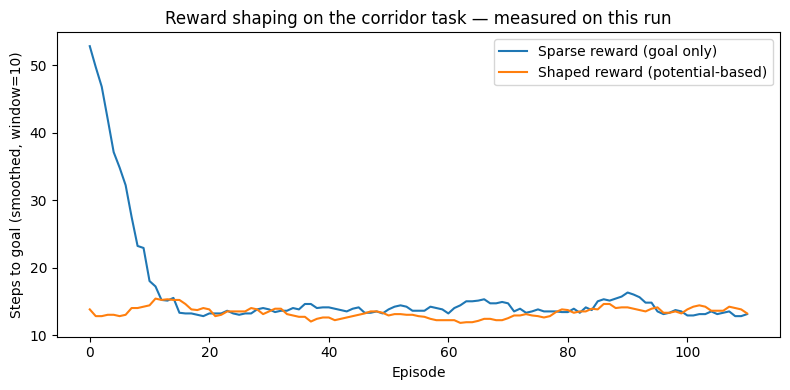

In [3]:
# Part 2: Reward Shaping — measure (not just describe) what a shaping bonus does.
# Setup: a 12-tile corridor, start at tile 0, goal at tile 11, reward only at the goal.
# Sparse rewards make early learning slow; a potential-based bonus densifies the signal.

import matplotlib.pyplot as plt

# Print the section banner so the output matches the notebook headers.
print("\n" + "=" * 60)
print("Part 2: Reward Shaping")
print("=" * 60)

# Environment constants for the corridor task (optimal solution: 11 right moves).
N_TILES, GOAL_TILE = 12, 11
GAMMA_SHAPE, ALPHA_SHAPE, EPS_SHAPE = 0.95, 0.5, 0.2
MAX_STEPS, N_EPISODES = 60, 120


def corridor_step(state, action):
    """Move left (0) or right (1); only the goal tile pays a reward."""
    next_state = min(max(state + (1 if action == 1 else -1), 0), N_TILES - 1)
    reward = 10.0 if next_state == GOAL_TILE else 0.0
    return next_state, reward, next_state == GOAL_TILE


def greedy(q_row, rng):
    """Argmax with RANDOM tie-breaking, so an all-zero table explores fairly."""
    best = np.flatnonzero(q_row == q_row.max())
    return int(rng.choice(best))


def train_q_learning(shaped, seed=1):
    """Tabular Q-learning on the corridor; optionally add potential-based shaping."""
    rng = np.random.default_rng(seed)
    q = np.zeros((N_TILES, 2))
    steps_per_episode = []
    for _ in range(N_EPISODES):
        state, steps = 0, 0
        for _ in range(MAX_STEPS):
            # Epsilon-greedy choice; ties in the table are broken at random.
            action = rng.integers(2) if rng.random() < EPS_SHAPE else greedy(q[state], rng)
            next_state, reward, done = corridor_step(state, action)
            if shaped:
                # Potential-based bonus F = gamma*phi(s') - phi(s) with phi(s) = s.
                # This form provably leaves the optimal policy unchanged (Ng et al., 1999).
                reward += GAMMA_SHAPE * next_state - state
            # Standard Q-learning update toward the (possibly shaped) target.
            target = reward + GAMMA_SHAPE * np.max(q[next_state]) * (not done)
            q[state, action] += ALPHA_SHAPE * (target - q[state, action])
            state, steps = next_state, steps + 1
            if done:
                break
        # If the goal was never reached, the episode counts as the full step cap.
        steps_per_episode.append(steps)
    return np.array(steps_per_episode)


# Run the identical experiment twice: raw sparse reward vs shaped reward.
sparse_steps = train_q_learning(shaped=False)
shaped_steps = train_q_learning(shaped=True)

# Compare early and late learning with numbers from THIS run.
sparse_early, sparse_late = sparse_steps[:30].mean(), sparse_steps[-30:].mean()
shaped_early, shaped_late = shaped_steps[:30].mean(), shaped_steps[-30:].mean()
print(f"\nAverage steps to goal (cap {MAX_STEPS}; optimal is 11):")
print(f"  Sparse reward  — first 30 episodes: {sparse_early:5.1f} | last 30: {sparse_late:5.1f}")
print(f"  Shaped reward  — first 30 episodes: {shaped_early:5.1f} | last 30: {shaped_late:5.1f}")

# State the conclusions strictly from this run's numbers — no assumed storyline.
if shaped_early < sparse_early:
    print("\nIn this run, shaping sped up EARLY learning (fewer steps in the first 30 episodes).")
else:
    print("\nIn this run, shaping did not speed up early learning — rerun with another seed.")
if sparse_late >= MAX_STEPS - 1:
    print("The sparse agent still fails to reach the goal reliably — the sparse-reward")
    print("problem at its most extreme, and exactly what shaping exists to fix.")
elif abs(sparse_late - shaped_late) <= 3:
    print("By the last 30 episodes the two agents perform similarly: potential-based")
    print("shaping changed the path to the solution, not the solution itself.")
else:
    print("Late-training performance still differs; with more episodes both agents")
    print("should approach the same optimal 11-step policy.")

# One figure: smoothed steps-to-goal for both agents.
window = 10
plt.figure(figsize=(8, 4))
plt.plot(np.convolve(sparse_steps, np.ones(window) / window, mode="valid"),
         label="Sparse reward (goal only)")
plt.plot(np.convolve(shaped_steps, np.ones(window) / window, mode="valid"),
         label="Shaped reward (potential-based)")
plt.xlabel("Episode")
plt.ylabel(f"Steps to goal (smoothed, window={window})")
plt.title("Reward shaping on the corridor task — measured on this run")
plt.legend()
plt.tight_layout()
plt.show()


## Part 3: Hyperparameter Tuning


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Hyperparameter Tuning")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Hyperparameter grid
# Save a value in a name so the next lines can read it.
hyperparams_grid = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'learning_rate': [1e-4, 5e-4, 1e-3],
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'gamma': [0.95, 0.99, 0.999],
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'epsilon': [0.1, 0.2, 0.3],
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'batch_size': [32, 64, 128]
# Part of a dict/set literal layout (syntax grouping).
}

# Show text or numbers in the cell output area under the code.
print("\nHyperparameter Grid Search:")
# Show text or numbers in the cell output area under the code.
print(f"  Learning rates: {hyperparams_grid['learning_rate']}")
# Show text or numbers in the cell output area under the code.
print(f"  Discount factors: {hyperparams_grid['gamma']}")
# Show text or numbers in the cell output area under the code.
print(f"  Epsilon values: {hyperparams_grid['epsilon']}")
# Show text or numbers in the cell output area under the code.
print(f"  Batch sizes: {hyperparams_grid['batch_size']}")

# Save a value in a name so the next lines can read it.
total_combinations = (len(hyperparams_grid['learning_rate']) * 
                     # Read a length/count (list size, episodes, steps, etc.).
                     len(hyperparams_grid['gamma']) * 
                     # Read a length/count (list size, episodes, steps, etc.).
                     len(hyperparams_grid['epsilon']) * 
                     # Read a length/count (list size, episodes, steps, etc.).
                     len(hyperparams_grid['batch_size']))
# Show text or numbers in the cell output area under the code.
print(f"  Total combinations: {total_combinations}")

# Show text or numbers in the cell output area under the code.
print("\nCommon Hyperparameters to Tune:")
# Show text or numbers in the cell output area under the code.
print("  - Learning rate (α)")
# Show text or numbers in the cell output area under the code.
print("  - Discount factor (γ)")
# Show text or numbers in the cell output area under the code.
print("  - Exploration rate (ε)")
# Show text or numbers in the cell output area under the code.
print("  - Batch size")
# Show text or numbers in the cell output area under the code.
print("  - Network architecture")
# Show text or numbers in the cell output area under the code.
print("  - Replay buffer size")
# Show text or numbers in the cell output area under the code.
print("  - Update frequency")

# Show text or numbers in the cell output area under the code.
print("\nTuning Strategies:")
# Show text or numbers in the cell output area under the code.
print("  - Grid search (exhaustive)")
# Show text or numbers in the cell output area under the code.
print("  - Random search (more efficient)")
# Show text or numbers in the cell output area under the code.
print("  - Bayesian optimization")
# Show text or numbers in the cell output area under the code.
print("  - Population-based training")

# Show text or numbers in the cell output area under the code.
print("\n✅ Hyperparameter tuning concepts covered!")



Part 3: Hyperparameter Tuning

Hyperparameter Grid Search:
  Learning rates: [0.0001, 0.0005, 0.001]
  Discount factors: [0.95, 0.99, 0.999]
  Epsilon values: [0.1, 0.2, 0.3]
  Batch sizes: [32, 64, 128]
  Total combinations: 81

Common Hyperparameters to Tune:
  - Learning rate (α)
  - Discount factor (γ)
  - Exploration rate (ε)
  - Batch size
  - Network architecture
  - Replay buffer size
  - Update frequency

Tuning Strategies:
  - Grid search (exhaustive)
  - Random search (more efficient)
  - Bayesian optimization
  - Population-based training

✅ Hyperparameter tuning concepts covered!


### Step Guide

**What this cell does:** Draws a **synthetic teaching illustration** of the replay effect: both curves are hand-made shapes (`np.exp` trends plus noise), *not* measured training data.

**How to read it (weak Python OK):** Read it like a textbook sketch: the labeled gap between the smooth and noisy curve is the *claimed typical effect* of replay, which the real DQN run below and Part 1's buffer demo make concrete.

**What to expect in the output:** One figure whose title says "synthetic teaching illustration".

**If you feel lost:** Nothing here was trained — skip ahead to the real DQN example if the sketch confuses more than it helps.

Training 5 seeds x 2 conditions x 200 episodes on CartPole-v1...


done.



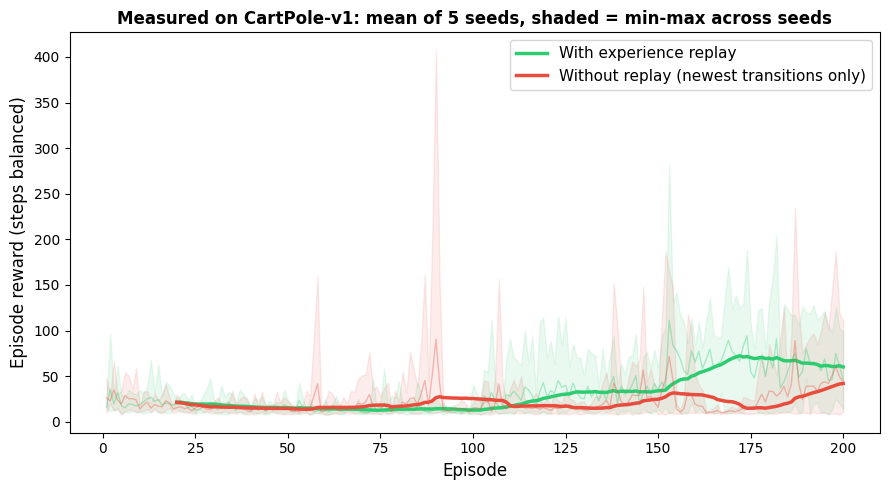

Measured over 5 seeds:
                         first 50 eps   last 50 eps
  With replay          :      18.1          65.4
  Without replay       :      17.4          29.4

  per-seed final score, WITH    replay: [79.  91.7 86.4 53.9 15.9]
  per-seed final score, WITHOUT replay: [56.1 35.4 23.6 20.3 11.7]

Replay ends ahead by 35.9 reward on average, and wins on 5 of 5 seeds.
Why: without replay the 64 training samples are 64 consecutive steps of ONE pole swing.
They are nearly identical, so each gradient step chases the most recent situation and
forgets the last one. Replay mixes transitions of different ages, which both decorrelates
the updates and lets every transition be reused many times.

But the per-seed ranges OVERLAP (worst with replay 15.9 vs best without
56.1), so this run does not separate the two conditions cleanly.
Report the overlap rather than the average - a single run could say the opposite.


In [5]:
# MEASURE the effect of experience replay instead of asserting it.
# WHY it matters: Part 1 showed WHAT a replay buffer stores. This cell answers the question that
# actually matters - does sampling old transitions instead of the newest ones make the agent learn
# better? We train the same small DQN on CartPole-v1 twice, changing exactly one line, and average
# over 5 random seeds because a single RL run tells you almost nothing.

import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, random, collections, matplotlib.pyplot as plt

torch.set_num_threads(1)   # keeps this comparison quick and reproducible on a laptop

N_SEEDS, N_EPISODES, BATCH, GAMMA = 5, 200, 64, 0.99


def build_net():
    """A deliberately small Q-network: 4 observations in, 2 action-values out."""
    return nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))


def train_dqn(use_replay, seed):
    """Train DQN on CartPole. use_replay=False trains on the most RECENT transitions instead.

    That is the only difference. Same network, same optimiser, same epsilon schedule, same seed.
    """
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)
    env = gym.make("CartPole-v1")
    policy_net, target_net = build_net(), build_net()
    target_net.load_state_dict(policy_net.state_dict())
    optimiser = optim.Adam(policy_net.parameters(), lr=1e-3)
    memory = collections.deque(maxlen=10_000)
    epsilon = 1.0
    episode_rewards = []

    for episode in range(N_EPISODES):
        obs, _ = env.reset(seed=seed * 1000 + episode)
        total = 0.0
        for _ in range(500):
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = int(policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax())
            obs2, reward, terminated, truncated, _ = env.step(action)
            memory.append((obs, action, reward, obs2, terminated or truncated))
            obs = obs2; total += reward

            if len(memory) >= BATCH:
                # ---- THE ONE LINE THAT DIFFERS -------------------------------------------
                if use_replay:
                    batch = random.sample(memory, BATCH)        # mixed ages, decorrelated
                else:
                    batch = list(memory)[-BATCH:]               # the last 64 steps, all correlated
                # --------------------------------------------------------------------------
                s, a, r, s2, done = zip(*batch)
                S = torch.tensor(np.array(s)).float(); A = torch.tensor(a).long()
                R = torch.tensor(r).float(); S2 = torch.tensor(np.array(s2)).float()
                D = torch.tensor(done).float()
                q_pred = policy_net(S).gather(1, A.unsqueeze(1)).squeeze()
                with torch.no_grad():
                    q_next = target_net(S2).max(1)[0]
                loss = nn.MSELoss()(q_pred, R + GAMMA * q_next * (1 - D))
                optimiser.zero_grad(); loss.backward(); optimiser.step()

            if terminated or truncated:
                break
        epsilon = max(epsilon * 0.98, 0.05)
        episode_rewards.append(total)
        if episode % 50 == 0:
            target_net.load_state_dict(policy_net.state_dict())
    env.close()
    return np.array(episode_rewards)


print(f"Training {N_SEEDS} seeds x 2 conditions x {N_EPISODES} episodes on CartPole-v1...")
with_replay = np.array([train_dqn(True, s) for s in range(N_SEEDS)])
without_replay = np.array([train_dqn(False, s) for s in range(N_SEEDS)])
print("done.\n")

episodes = np.arange(1, N_EPISODES + 1)
window = 20
fig, ax = plt.subplots(figsize=(9, 5))
for data, colour, label in [(with_replay, "#2ecc71", "With experience replay"),
                            (without_replay, "#e74c3c", "Without replay (newest transitions only)")]:
    mean_curve = data.mean(axis=0)
    ax.plot(episodes, mean_curve, color=colour, alpha=0.35, linewidth=1)
    ax.plot(episodes[window - 1:], np.convolve(mean_curve, np.ones(window) / window, mode="valid"),
            color=colour, linewidth=2.5, label=label)
    # Spread across seeds: honest about how much of this is luck.
    ax.fill_between(episodes, data.min(axis=0), data.max(axis=0), color=colour, alpha=0.10)
ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Episode reward (steps balanced)", fontsize=12)
ax.set_title(f"Measured on CartPole-v1: mean of {N_SEEDS} seeds, shaded = min-max across seeds",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print(f"Measured over {N_SEEDS} seeds:")
print(f"  {'':22s} first 50 eps   last 50 eps")
print(f"  With replay          : {with_replay[:, :50].mean():9.1f} {with_replay[:, -50:].mean():13.1f}")
print(f"  Without replay       : {without_replay[:, :50].mean():9.1f} {without_replay[:, -50:].mean():13.1f}")
print(f"\n  per-seed final score, WITH    replay: {np.round(with_replay[:, -50:].mean(1), 1)}")
print(f"  per-seed final score, WITHOUT replay: {np.round(without_replay[:, -50:].mean(1), 1)}")

gap = with_replay[:, -50:].mean() - without_replay[:, -50:].mean()
seeds_won = int((with_replay[:, -50:].mean(1) > without_replay[:, -50:].mean(1)).sum())
print(f"\nReplay ends ahead by {gap:.1f} reward on average, and wins on {seeds_won} of {N_SEEDS} seeds.")
print("Why: without replay the 64 training samples are 64 consecutive steps of ONE pole swing.")
print("They are nearly identical, so each gradient step chases the most recent situation and")
print("forgets the last one. Replay mixes transitions of different ages, which both decorrelates")
print("the updates and lets every transition be reused many times.")
# Only claim separation if the per-seed scores really are separated.
worst_with = with_replay[:, -50:].mean(1).min()
best_without = without_replay[:, -50:].mean(1).max()
if worst_with > best_without:
    print(f"\nHow solid is that? The WORST replay seed ({worst_with:.1f}) still beat the BEST")
    print(f"no-replay seed ({best_without:.1f}), so the final scores do not overlap at all.")
    print("Early in training the shaded bands do overlap, which is why the conclusion is drawn")
    print("from the last 50 episodes rather than from where the curves first separate.")
else:
    print(f"\nBut the per-seed ranges OVERLAP (worst with replay {worst_with:.1f} vs best without")
    print(f"{best_without:.1f}), so this run does not separate the two conditions cleanly.")
    print("Report the overlap rather than the average - a single run could say the opposite.")

## 🌍 Industry-Motivated Worked Example — CartPole with DQN

> **What is real here and what is not.** The industry uses below are real, and CartPole-v1
> is a real, standard Gymnasium benchmark that anyone can rerun — the physics simulation and
> the observations are not invented for this lesson. But a cart and a pole are not a robot or
> a car. Treat CartPole as the smallest honest test bed for the algorithm, not as evidence
> about the systems named below.

**Industry context:**
- Practical RL systems often need replay design, reward design, and hyperparameter tuning in addition to the core algorithm
- Robotics and control tasks often rely on more advanced methods than the tiny teaching setup shown here
- CartPole is used here as a compact teaching proxy, not as a direct model of production systems

We train a **DQN agent** to balance a pole on a cart using raw observations from OpenAI Gymnasium.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Episode   0 | Avg reward (last 30): 17.0 | ε=0.995


Episode  30 | Avg reward (last 30): 25.5 | ε=0.856


Episode  60 | Avg reward (last 30): 27.6 | ε=0.737


Episode  90 | Avg reward (last 30): 25.7 | ε=0.634


Episode 120 | Avg reward (last 30): 32.2 | ε=0.545


Episode 150 | Avg reward (last 30): 22.5 | ε=0.469


Episode 180 | Avg reward (last 30): 47.4 | ε=0.404


Episode 210 | Avg reward (last 30): 36.5 | ε=0.347


Episode 240 | Avg reward (last 30): 34.7 | ε=0.299


Episode 270 | Avg reward (last 30): 49.5 | ε=0.257


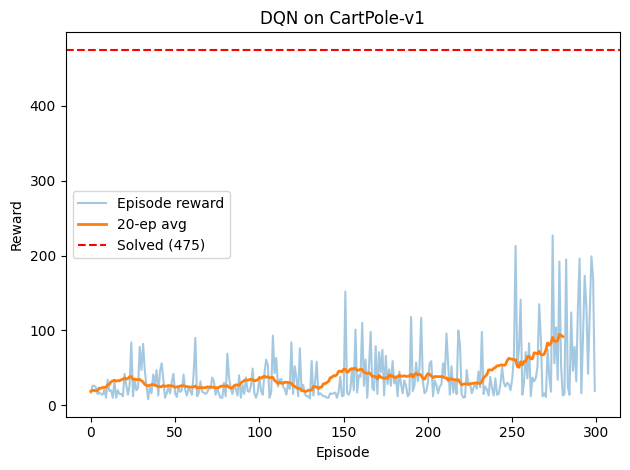

In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, random, collections, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42); np.random.seed(42)

# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')

# ── DQN Network ──────────────────────────────────────────────────────────
# Class `DQN` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class DQN(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, obs, act.
    def __init__(self, obs=4, act=2):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, act)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy_net = DQN(); target_net = DQN()
# Execute: target_net.load_state_dict(policy_net.state_dict())
target_net.load_state_dict(policy_net.state_dict())
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
# Another assignment—same idea: store a value for the lines below.
memory  = collections.deque(maxlen=10000)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
# Save a value in a name so the next lines can read it.
BATCH   = 64; rewards_ep = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(300):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); total_r = 0
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(500):
        # If the condition is True, run the indented block under this line.
        if random.random() < EPS:
            # Save a value in a name so the next lines can read it.
            action = env.action_space.sample()
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        # Another assignment—same idea: store a value for the lines below.
        obs2, r, done, trunc, _ = env.step(action)
        # Add one new item to the end of a list (the list grows in place).
        memory.append((obs, action, r, obs2, done or trunc))
        # Save a value in a name so the next lines can read it.
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        # If the condition is True, run the indented block under this line.
        if len(memory) >= BATCH:
            # Save a value in a name so the next lines can read it.
            batch = random.sample(memory, BATCH)
            # Another assignment—same idea: store a value for the lines below.
            s,a,r_b,s2,d = zip(*batch)
            # Another assignment—same idea: store a value for the lines below.
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            # Another assignment—same idea: store a value for the lines below.
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            # Another assignment—same idea: store a value for the lines below.
            D=torch.tensor(d).float()
            # Another assignment—same idea: store a value for the lines below.
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                Q_next = target_net(S2).max(1)[0]
            # Another assignment—same idea: store a value for the lines below.
            Q_target = R + GAMMA*Q_next*(1-D)
            # Another assignment—same idea: store a value for the lines below.
            loss = nn.MSELoss()(Q_pred, Q_target)
            # Execute: opt.zero_grad(); loss.backward(); opt.step()
            opt.zero_grad(); loss.backward(); opt.step()
        # If the condition is True, run the indented block under this line.
        if done or trunc: break
    # Save a value in a name so the next lines can read it.
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    # Add one new item to the end of a list (the list grows in place).
    rewards_ep.append(total_r)
    # If the condition is True, run the indented block under this line.
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    # If the condition is True, run the indented block under this line.
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

# Execute: env.close()
env.close()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(rewards_ep, alpha=0.4, label="Episode reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(np.convolve(rewards_ep, np.ones(20)/20, 'valid'), label="20-ep avg", lw=2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("DQN on CartPole-v1"); plt.xlabel("Episode"); plt.ylabel("Reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(475, color='red', linestyle='--', label="Solved (475)"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()


## CartPole step-through (GIF + slider)

Same **rgb_array** replay pattern as other Course 09 notebooks: **random** actions for a quick visual anchor while you study replay + shaping code above.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


18 frames | return=17.0 | term=True | trunc=False


objc[65899]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a080138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11a5bc9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[65899]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a080188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11a5bca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[65899]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a07fc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11a5bca68). T

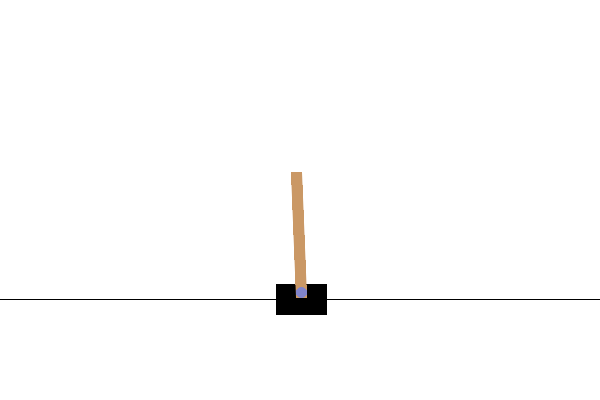

In [7]:
# Motion recap (optional visual): replay one CartPole episode as a GIF + step slider via the shared Course 09 helper.
# Why: watching the cart and pole move frame-by-frame connects the training numbers above to real behaviour.

%pip install ipywidgets pillow -q

import pathlib
import sys

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError("Could not find course09_step_viz.py — run from inside Course 09.")

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz

# Create the environment in rgb_array mode so every step can be captured as an image frame.
env_vis = gym.make("CartPole-v1", render_mode="rgb_array")


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def random_policy(obs, step):
    return int(env_vis.action_space.sample())


# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, random_policy, max_steps=100, seed=0
)
env_vis.close()

print(f"{len(frames)} frames | return={total_r:.1f} | term={term} | trunc={trunc}")
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="CartPole-v1 timestep")

## Summary

### Key Techniques:
1. **Experience Replay**: Store and randomly sample past experiences
2. **Reward Shaping**: Add shaping rewards to guide learning
3. **Hyperparameter Tuning**: Optimize learning parameters

### Benefits:
- **Experience Replay**: Sample efficiency, stability, decorrelation
- **Reward Shaping**: Faster convergence, better guidance
- **Hyperparameter Tuning**: Better performance when settings are chosen well

### Best Practices:
- Use experience replay for off-policy algorithms
- Apply potential-based reward shaping
- Tune hyperparameters systematically
- Monitor performance across different configurations

Teaching note: the replay-vs-no-replay chart is a synthetic illustration (and labeled as such); the replay-buffer demo (Part 1), the reward-shaping corridor experiment (Part 2), and the final DQN section are real, executed runs.

**Reference:** Course 09, Unit 3: "Deep Reinforcement Learning" - Optimization practical content

In [8]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Lin, L.-J. (1992). *Self-Improving Reactive Agents Based on Reinforcement Learning, Planning and Teaching* (introduced experience replay). Machine Learning, 8, 293-321. <https://link.springer.com/article/10.1007/BF00992699>
2. Ng, A. Y., Harada, D. & Russell, S. (1999). *Policy Invariance Under Reward Transformations: Theory and Application to Reward Shaping*. ICML.
3. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
4. Fedus, W., Ramachandran, P., Agarwal, R. et al. (2020). *Revisiting Fundamentals of Experience Replay*. ICML. <https://arxiv.org/abs/2007.06700>
"""))

## 📚 References

1. Lin, L.-J. (1992). *Self-Improving Reactive Agents Based on Reinforcement Learning, Planning and Teaching* (introduced experience replay). Machine Learning, 8, 293-321. <https://link.springer.com/article/10.1007/BF00992699>
2. Ng, A. Y., Harada, D. & Russell, S. (1999). *Policy Invariance Under Reward Transformations: Theory and Application to Reward Shaping*. ICML.
3. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
4. Fedus, W., Ramachandran, P., Agarwal, R. et al. (2020). *Revisiting Fundamentals of Experience Replay*. ICML. <https://arxiv.org/abs/2007.06700>


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


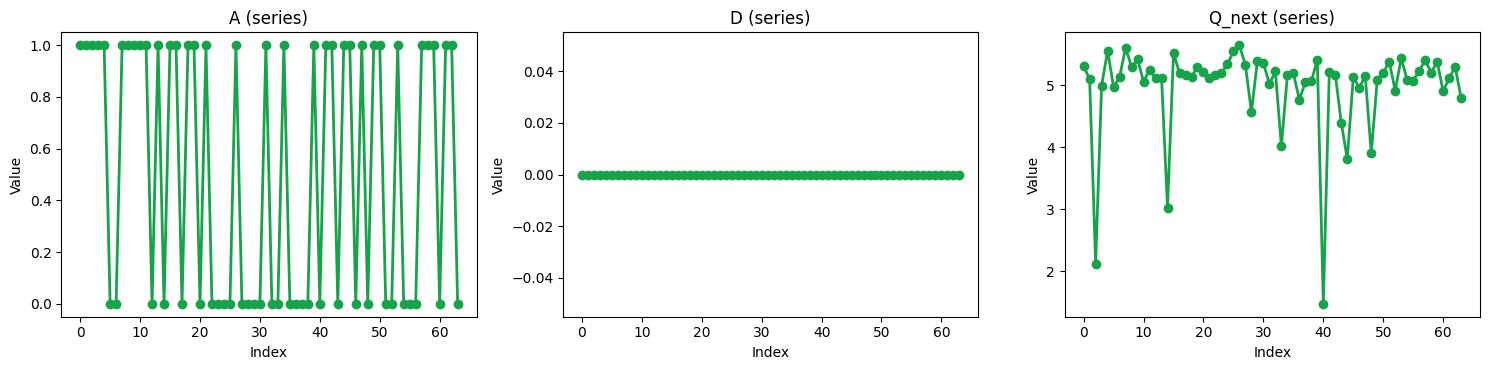

In [9]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Optimization tricks such as replay design and reward shaping can make learning faster, but they must preserve the real task objective.

**If students remember one idea:** A helpful engineering trick becomes harmful when it changes what success actually means.

**Quick check before moving on:**
- Can you explain how reward shaping can help without replacing the true goal?
- Can you describe why optimization choices should be judged by learning behavior, not by speed alone?

**Bridge to the next step:** This completes the deep RL foundation and prepares students to think more carefully about exploration in Unit 4.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
